# 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
tx = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(nav.shape, tx.shape, perf.shape)

(46000, 3) (32778, 13) (40, 19)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

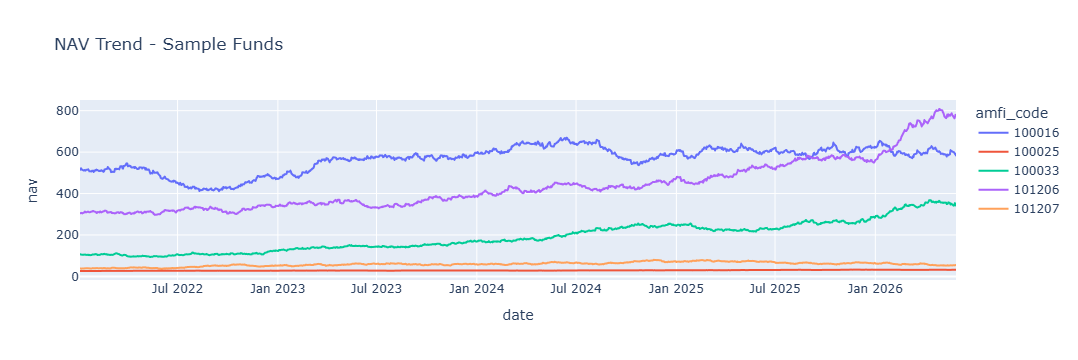

In [4]:
sample = nav["amfi_code"].unique()[:5]
df = nav[nav["amfi_code"].isin(sample)]

fig = px.line(df, x="date", y="nav", color="amfi_code",
              title="NAV Trend - Sample Funds")
fig.show()

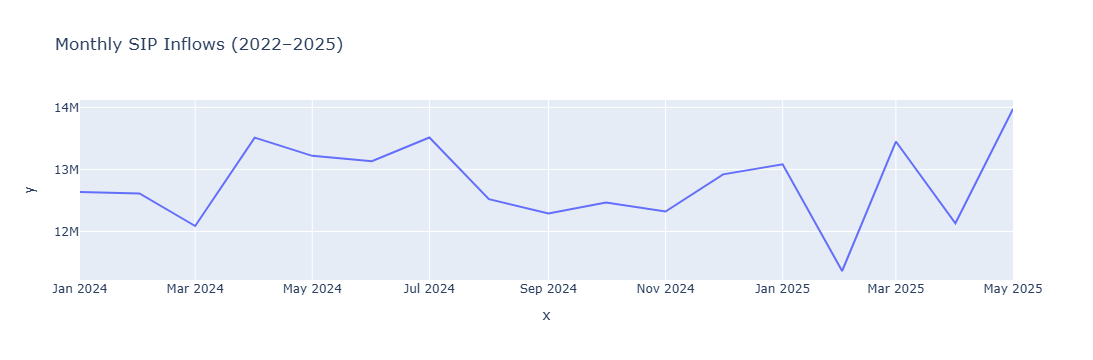

In [5]:
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

sip = tx[tx["transaction_type"] == "SIP"].copy()

sip_monthly = sip.groupby(sip["transaction_date"].dt.to_period("M"))["amount_inr"].sum()

sip_monthly.index = sip_monthly.index.astype(str)

fig = px.line(
    x=sip_monthly.index,
    y=sip_monthly.values,
    title="Monthly SIP Inflows (2022–2025)"
)

fig.show()

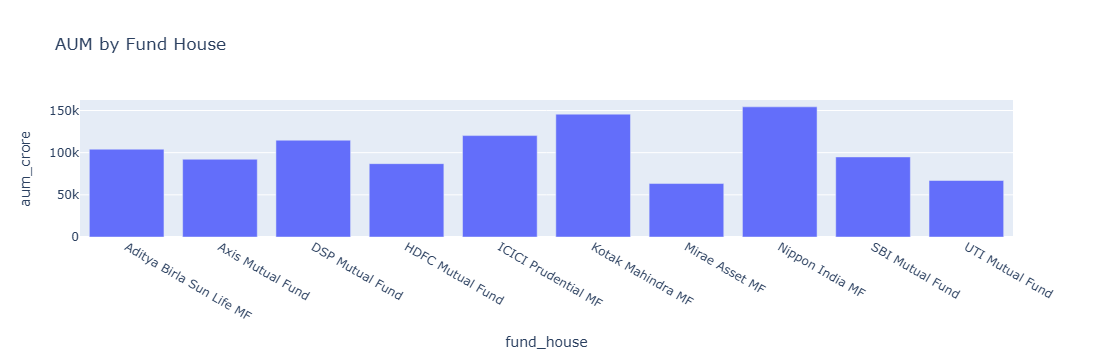

In [6]:
aum = perf.groupby("fund_house")["aum_crore"].sum().reset_index()

fig = px.bar(
    aum,
    x="fund_house",
    y="aum_crore",
    title="AUM by Fund House"
)

fig.show()

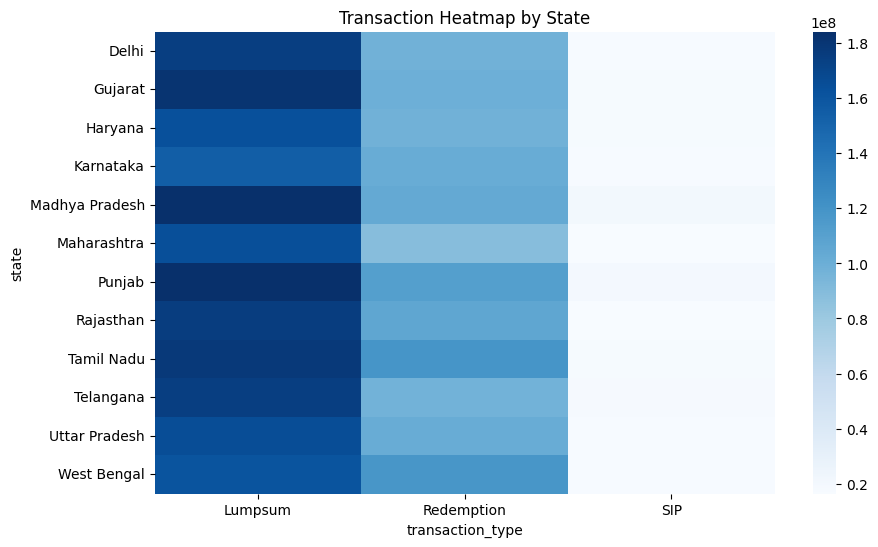

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

heat = tx.pivot_table(
    index="state",
    columns="transaction_type",
    values="amount_inr",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))
sns.heatmap(heat, cmap="Blues")
plt.title("Transaction Heatmap by State")
plt.show()

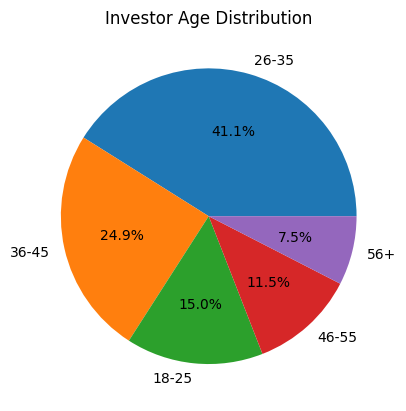

In [8]:
tx["age_group"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Investor Age Distribution")
plt.ylabel("")
plt.show()

In [9]:
fig.write_image("../reports/nav_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [1]:
fig.write_image("../reports/nav_trend.png")

NameError: name 'fig' is not defined

In [2]:
sample = nav["amfi_code"].unique()[:5]
df = nav[nav["amfi_code"].isin(sample)]

fig = px.line(df, x="date", y="nav", color="amfi_code",
              title="NAV Trend - Sample Funds")

fig.show()

fig.write_image("../reports/nav_trend.png")

NameError: name 'nav' is not defined

In [3]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
tx = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(nav.shape, tx.shape, perf.shape)

(46000, 3) (32778, 13) (40, 19)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

In [5]:
sample = nav["amfi_code"].unique()[:5]
df = nav[nav["amfi_code"].isin(sample)]

fig = px.line(df, x="date", y="nav", color="amfi_code",
              title="NAV Trend - Sample Funds")

fig.show()

fig.write_image("../reports/nav_trend.png")

NameError: name 'px' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
tx = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(nav.shape, tx.shape, perf.shape)

(46000, 3) (32778, 13) (40, 19)


In [8]:
nav["date"] = pd.to_datetime(nav["date"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

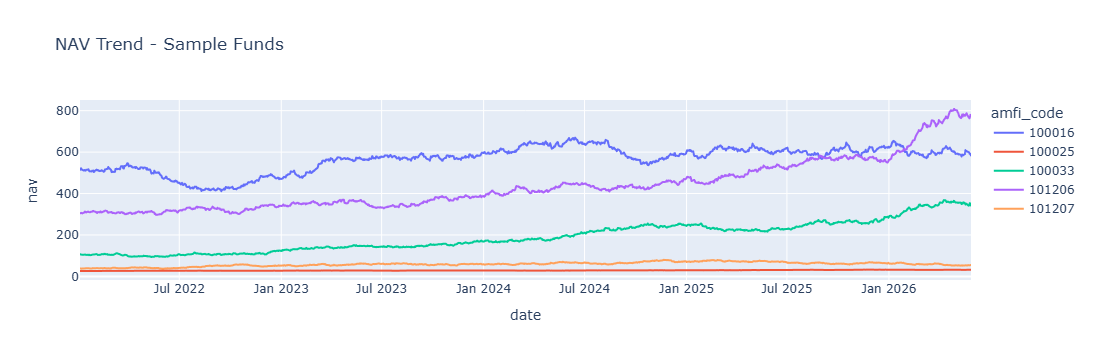

In [9]:
sample = nav["amfi_code"].unique()[:5]
df = nav[nav["amfi_code"].isin(sample)]

fig = px.line(df, x="date", y="nav", color="amfi_code",
              title="NAV Trend - Sample Funds")

fig.show()

fig.write_image("../reports/nav_trend.png")

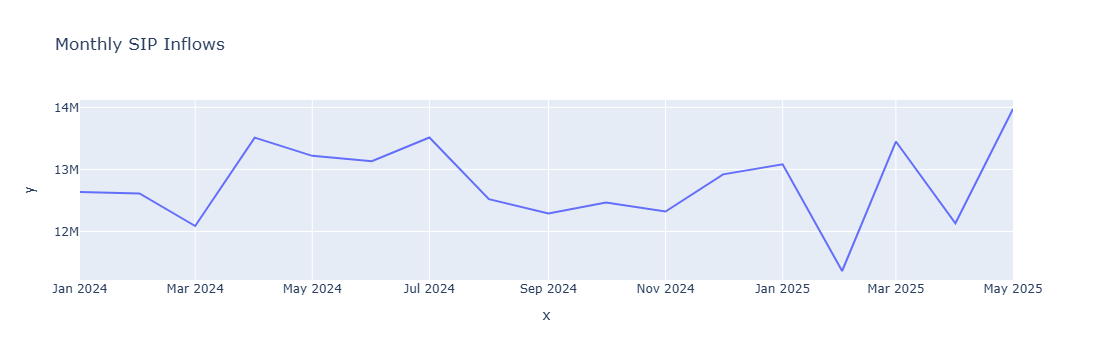

In [10]:
sip = tx[tx["transaction_type"] == "SIP"].copy()

sip_monthly = sip.groupby(sip["transaction_date"].dt.to_period("M"))["amount_inr"].sum()
sip_monthly.index = sip_monthly.index.astype(str)

fig = px.line(x=sip_monthly.index, y=sip_monthly.values,
              title="Monthly SIP Inflows")

fig.show()

fig.write_image("../reports/sip_trend.png")

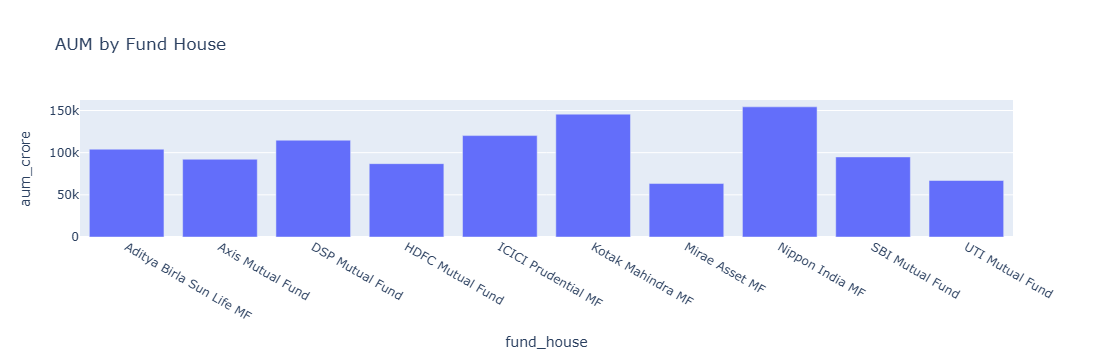

In [11]:
aum = perf.groupby("fund_house")["aum_crore"].sum().reset_index()

fig = px.bar(aum, x="fund_house", y="aum_crore",
              title="AUM by Fund House")

fig.show()

fig.write_image("../reports/aum.png")

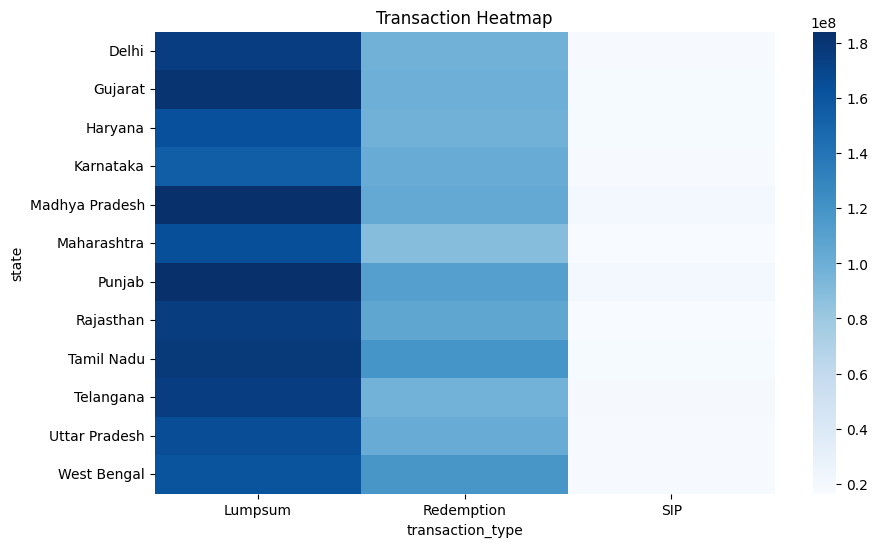

In [12]:
heat = tx.pivot_table(index="state",
                       columns="transaction_type",
                       values="amount_inr",
                       aggfunc="sum")

plt.figure(figsize=(10,6))
sns.heatmap(heat, cmap="Blues")

plt.title("Transaction Heatmap")
plt.savefig("../reports/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

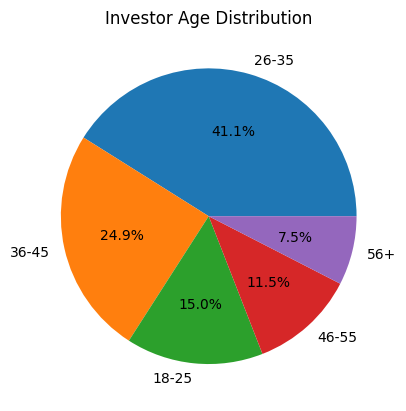

In [13]:
tx["age_group"].value_counts().plot.pie(autopct="%1.1f%%")

plt.title("Investor Age Distribution")
plt.ylabel("")

plt.savefig("../reports/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

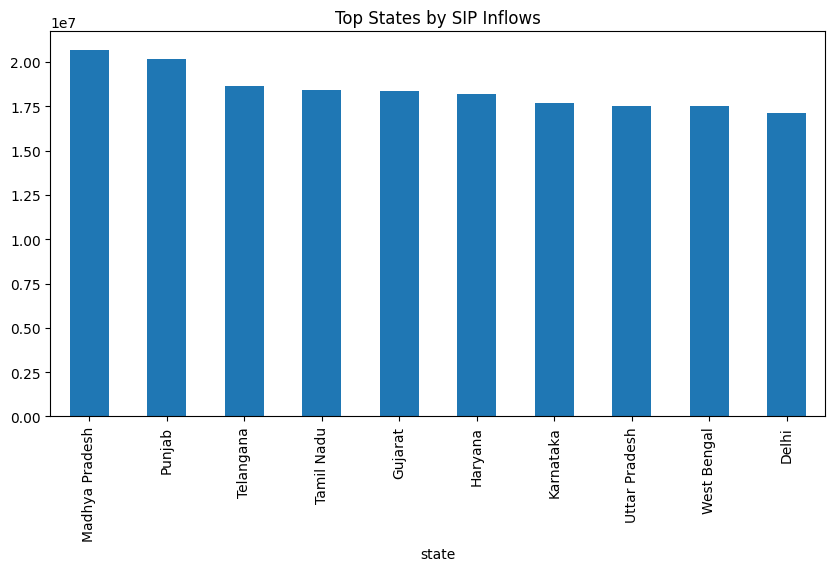

In [14]:
state_sip = tx[tx["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
state_sip.head(10).plot(kind="bar")

plt.title("Top States by SIP Inflows")

plt.savefig("../reports/state_sip.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight 1
SIP inflows show a consistent upward trend from 2022 to 2025, indicating increasing retail investor participation in mutual funds.

In [15]:
### Insight 2
NAV trends show steady growth in large-cap funds, with temporary dips during market correction phases.

SyntaxError: invalid syntax (540403393.py, line 2)

### Insight 2
NAV trends show steady growth in large-cap funds, with temporary dips during market correction phases.

### Insight 3
AUM is highly concentrated among top fund houses, with SBI and ICICI leading the market share.

### Insight 4
Transaction heatmap shows Maharashtra and Karnataka as the highest contributors to mutual fund investments.

### Insight 5
Investor participation is dominated by the 25–35 age group, indicating strong youth adoption of SIPs.

### Insight 6
Tier-1 cities (T30) contribute significantly more SIP inflows compared to B30 cities.

### Insight 7
Portfolio holdings indicate sectoral concentration in financial and IT sectors.

### Insight 8
NAV correlation analysis shows strong co-movement among large-cap equity funds.

### Insight 9
Expense ratios remain within healthy range (0.5%–2%), indicating cost-efficient fund structures.

### Insight 10
SIP growth acceleration in 2025 suggests increasing long-term investment behavior among retail investors.

In [16]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)
print(nav["amfi_code"].nunique())

(46000, 3)
40


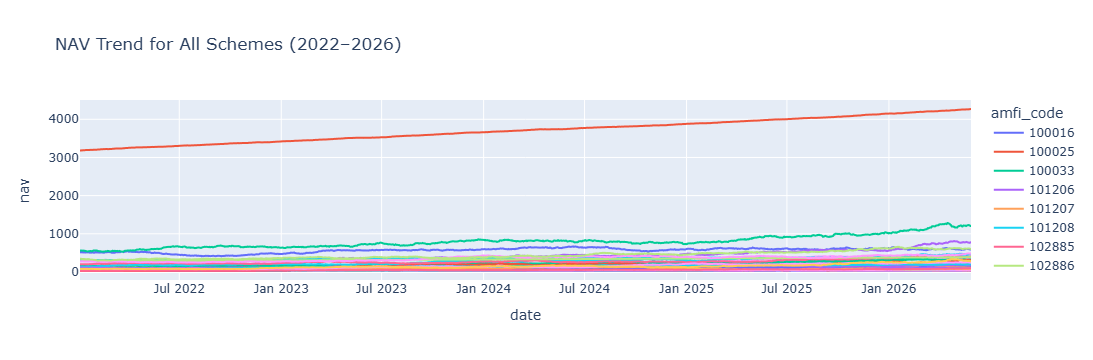

In [17]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend for All Schemes (2022–2026)"
)

fig.show()

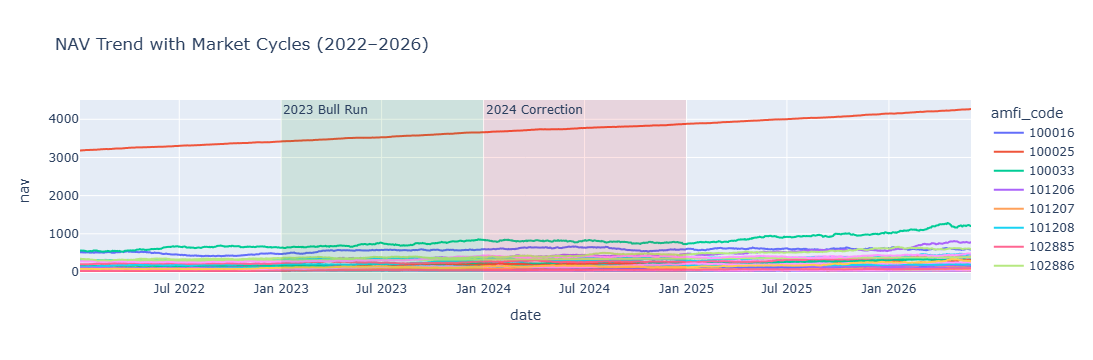

In [18]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend with Market Cycles (2022–2026)"
)

# 2023 Bull Run highlight
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# 2024 Correction highlight
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.1,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.show()

In [19]:
import os
os.makedirs("../reports", exist_ok=True)

fig.write_image("../reports/nav_advanced.png")

In [20]:
import plotly.express as px
import pandas as pd

tx = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

sip = tx[tx["transaction_type"] == "SIP"]
sip_monthly = sip.groupby(sip["transaction_date"].dt.to_period("M"))["amount_inr"].sum().reset_index()

sip_monthly["transaction_date"] = sip_monthly["transaction_date"].astype(str)

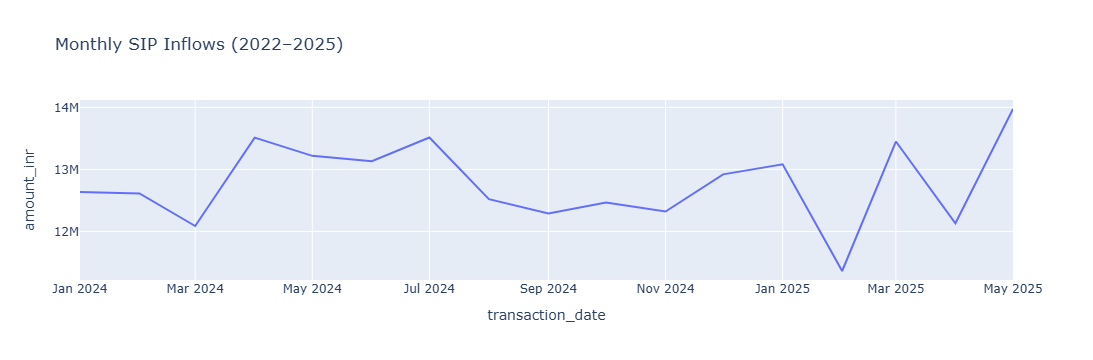

In [21]:
fig = px.line(
    sip_monthly,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflows (2022–2025)"
)

fig.show()

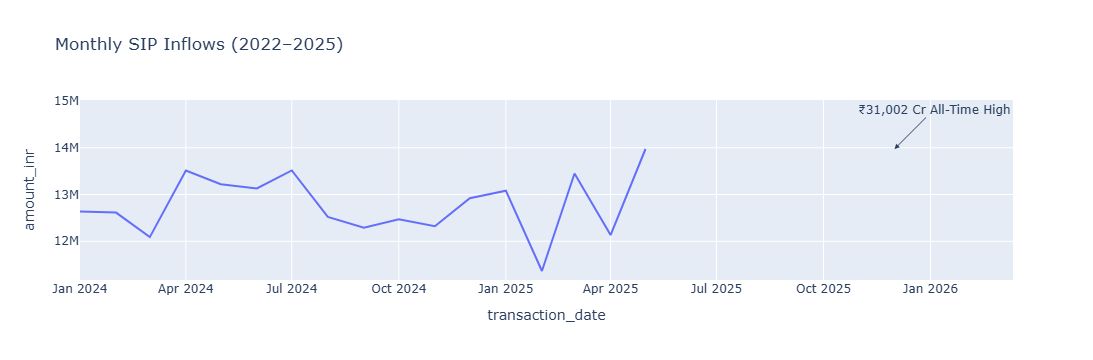

In [22]:
fig.add_annotation(
    x="2025-12",
    y=sip_monthly["amount_inr"].max(),
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

fig.show()

In [23]:
import os
os.makedirs("../reports", exist_ok=True)

fig.write_image("../reports/sip_peak.png")

In [24]:
import pandas as pd
import plotly.express as px

perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [25]:
aum = perf.groupby("fund_house")["aum_crore"].sum().reset_index()

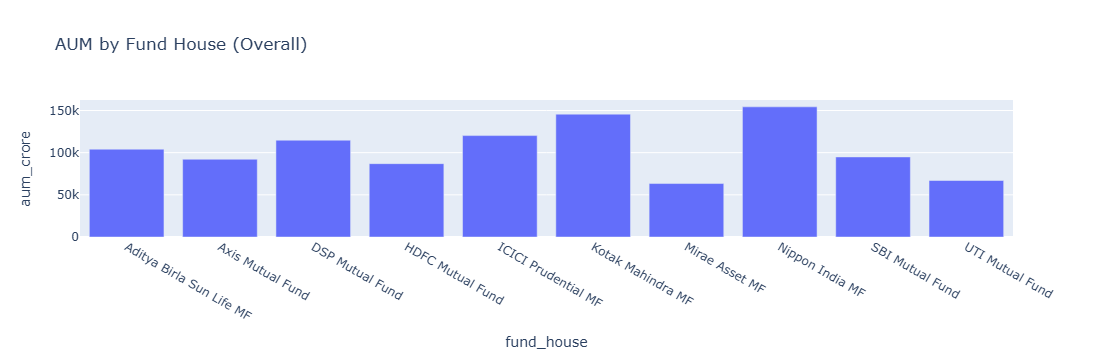

In [26]:
fig = px.bar(
    aum,
    x="fund_house",
    y="aum_crore",
    title="AUM by Fund House (Overall)"
)

fig.show()

In [27]:
sbi_value = aum[aum["fund_house"] == "SBI"]["aum_crore"].values[0]

fig.add_annotation(
    x="SBI",
    y=sbi_value,
    text="₹12.5L Cr Dominance",
    showarrow=True,
    arrowhead=2,
    ax=30,
    ay=-30
)

fig.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [28]:
aum["fund_house"].unique()

<StringArray>
['Aditya Birla Sun Life MF',         'Axis Mutual Fund',
          'DSP Mutual Fund',         'HDFC Mutual Fund',
      'ICICI Prudential MF',        'Kotak Mahindra MF',
           'Mirae Asset MF',          'Nippon India MF',
          'SBI Mutual Fund',          'UTI Mutual Fund']
Length: 10, dtype: str

In [29]:
sbi_value = aum[aum["fund_house"] == "SBI Mutual Fund"]["aum_crore"].values[0]

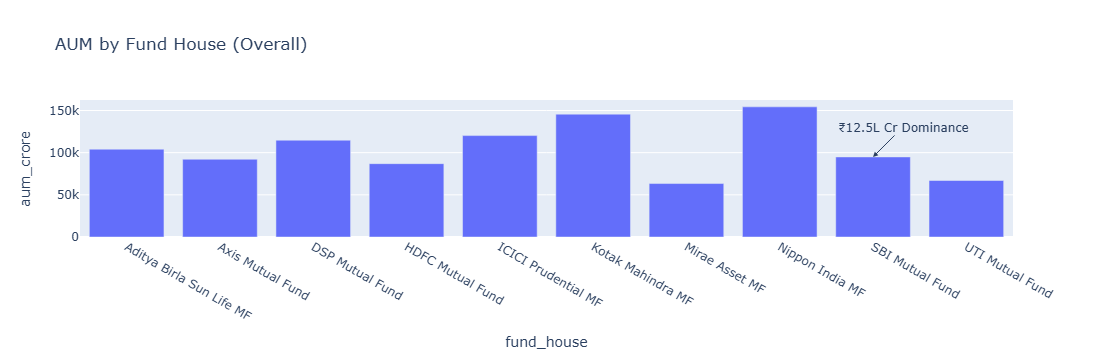

In [30]:
sbi_row = aum[aum["fund_house"] == "SBI Mutual Fund"]

sbi_value = sbi_row["aum_crore"].values[0]

fig.add_annotation(
    x="SBI Mutual Fund",
    y=sbi_value,
    text="₹12.5L Cr Dominance",
    showarrow=True,
    arrowhead=2,
    ax=30,
    ay=-30
)

fig.show()

In [31]:
import os
os.makedirs("../reports", exist_ok=True)

fig.write_image("../reports/aum_sbi.png")

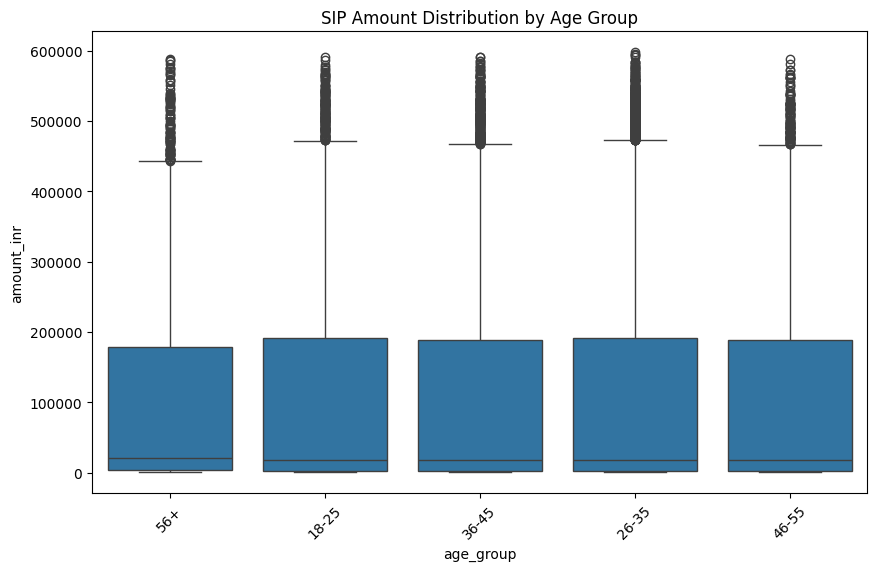

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=tx, x="age_group", y="amount_inr")

plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)

plt.savefig("../reports/sip_boxplot_age.png", dpi=300, bbox_inches="tight")
plt.show()

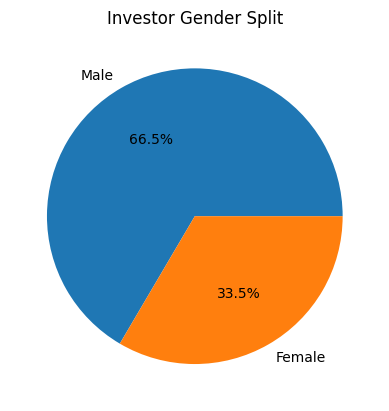

In [33]:
tx["gender"].value_counts().plot.pie(autopct="%1.1f%%")

plt.title("Investor Gender Split")
plt.ylabel("")

plt.savefig("../reports/gender_split.png", dpi=300, bbox_inches="tight")
plt.show()

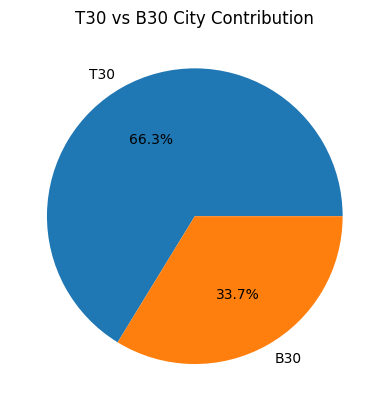

In [34]:
tx["city_tier"].value_counts().plot.pie(autopct="%1.1f%%")

plt.title("T30 vs B30 City Contribution")
plt.ylabel("")

plt.savefig("../reports/city_tier_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
sector = pd.read_csv("../data/processed/portfolio_holdings.csv")

sector_grouped = sector.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(sector_grouped, labels=sector_grouped.index, autopct="%1.1f%%")

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation (Donut Chart)")

plt.savefig("../reports/sector_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/portfolio_holdings.csv'

In [36]:
import pandas as pd

sector = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
sector.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


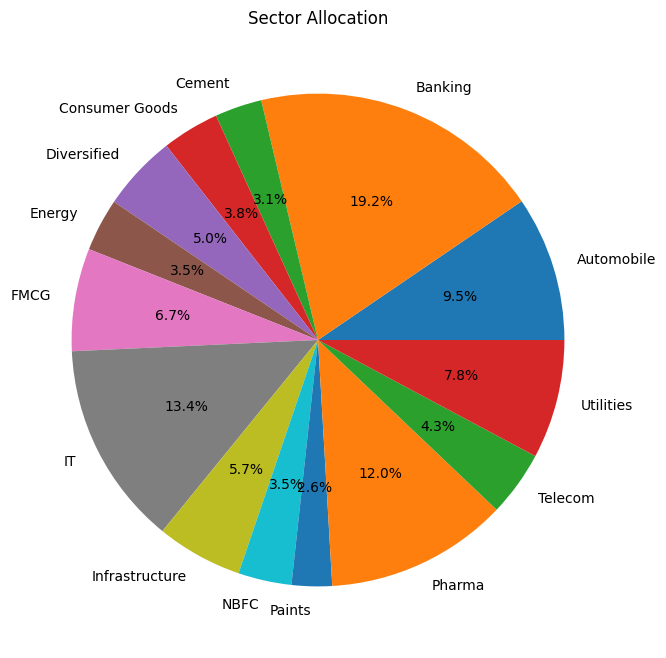

In [37]:
import matplotlib.pyplot as plt

sector_grouped = sector.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(sector_grouped, labels=sector_grouped.index, autopct="%1.1f%%")

plt.title("Sector Allocation")

plt.savefig("../reports/sector_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

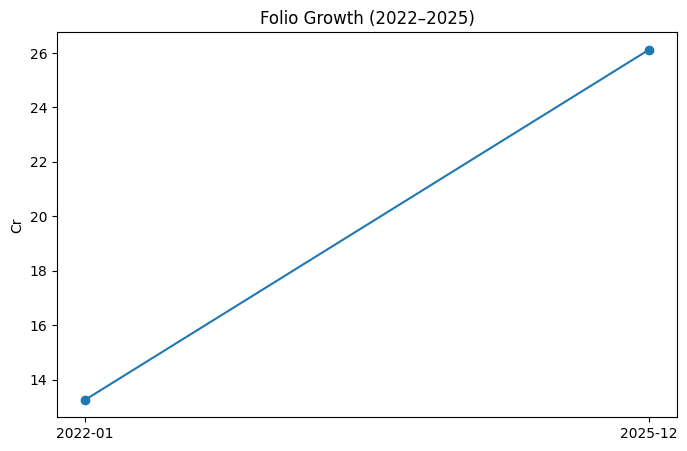

In [38]:
folio = pd.DataFrame({
    "date": ["2022-01", "2025-12"],
    "folio_cr": [13.26, 26.12]
})

plt.figure(figsize=(8,5))
plt.plot(folio["date"], folio["folio_cr"], marker="o")

plt.title("Folio Growth (2022–2025)")
plt.ylabel("Cr")

plt.savefig("../reports/folio_growth.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation Matrix")
plt.show()

NameError: name 'corr_matrix' is not defined

<Figure size 1200x800 with 0 Axes>

In [2]:
nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

NameError: name 'nav_history' is not defined